# Plant Detection using TensorFlow Object Detection API

This notebook demonstrates training and evaluation of an object detection model
for plant instance detection on the :contentReference[oaicite:0]{index=0} dataset.

We fine-tune a pre-trained SSD model:
- Model: SSD MobileNet V2 FPNLite (320×320)
- Framework: TensorFlow Object Detection API (TF 2.11)
- Task: Crop vs Weed detection

The notebook covers:
1. Environment setup
2. Dataset loading
3. Model configuration
4. Training and evaluation
5. Qualitative inference results

## Environment Setup

This experiment is designed for:
- Python 3.10
- TensorFlow 2.11
- CUDA-enabled GPU

On Kaggle:
Enable "Pin to original environment" to avoid version drift.

In [1]:
!python -V

Python 3.10.10


In [2]:
# --- Core: minimal + compatible setup for TF 2.11 OD API ---

!pip install -q \
  numpy==1.22.4 \
  scipy==1.10.1 \
  protobuf==3.20.3 \
  tf_slim \
  pycocotools \
  lvis \
  Cython \
  contextlib2 \
  pillow \
  matplotlib \
  gin-config \
  tf-models-official==2.11.0 --no-deps

In [3]:
!pip install \
  --upgrade \
  --force-reinstall \
  --no-cache-dir \
  --no-deps \
  git+https://github.com/frdiener/agri-vision-edge.git

  Cloning https://github.com/frdiener/agri-vision-edge.git to /tmp/pip-req-build-s9rmgotm
  Running command git clone --filter=blob:none --quiet https://github.com/frdiener/agri-vision-edge.git /tmp/pip-req-build-s9rmgotm
  Resolved https://github.com/frdiener/agri-vision-edge.git to commit fe8f08d3647d6a08f9f0ec7bb836ca569359f031
  Installing build dependencies ... - \ | / - done
  Getting requirements to build wheel ... - done
  Preparing metadata (pyproject.toml) ... - done
  Created wheel for agri-vision-edge: filename=agri_vision_edge-0.1.0-py3-none-any.whl size=1790987 sha256=2c567dc37ef52b9a13396bbaa5cbfe32240e493fc8dbe66bae5922fb4984c68b
  Stored in directory: /tmp/pip-ephem-wheel-cache-ne1_ujmo/wheels/47/ca/b5/23e0d1c70f8dbe929aaa72754dafc87b1c07721c0795e427ff
Successfully built agri-vision-edge


In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("GPU ready:", gpus)

GPU ready: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
from agri_vision_edge.third_party import setup_tensorflow_models
setup_tensorflow_models()

import object_detection
import google.protobuf

print("TF:", tf.__version__)
print("protobuf:", google.protobuf.__version__)

TF: 2.11.0
protobuf: 3.20.3


## Dataset

We use preprocessed TFRecord files derived from :contentReference[oaicite:1]{index=1}.

Additionally, raw images are used for qualitative evaluation.

In [6]:
from pathlib import Path
import agri_vision_edge

dataset_dir = Path("/kaggle/input/datasets/freimutdiener/phenobench-tfrecord-dataset-for-tensorflow-od")
dataset_raw_dir = Path("/kaggle/input/datasets/freimutdiener/phenobench-raw-dataset-v1-1-0/PhenoBench")

label_map_path = dataset_dir / "label_map.pbtxt"
train_record = dataset_dir / "train.record"
val_record = dataset_dir / "val.record"

test_imgs = list((dataset_raw_dir / "test" / "images").glob("*.png"))

print(f"{len(test_imgs)} test images loaded")

693 test images loaded


## Model Configuration

We fine-tune a pre-trained SSD model:
- Backbone: MobileNetV2
- Feature extractor: FPNLite
- Input size: 320×320

We adapt:
- number of classes
- learning rate schedule
- dataset paths

In [7]:
from agri_vision_edge.tfod import configure_ssd_pipeline

MODEL_DIR = Path("/kaggle/input/models/freimutdiener/ssd-mobilenet-v2-320x320/tensorflow2/coco17/1/ssd_mobilenet_v2_320x320_coco17_tpu-8")

PIPELINE_CONFIG = Path("/kaggle/working/pipeline.config")

configure_ssd_pipeline(
    config_path=MODEL_DIR / "pipeline.config",
    output_path=PIPELINE_CONFIG,
    train_record=train_record,
    val_record=val_record,
    label_map=label_map_path,
    checkpoint_path=MODEL_DIR / "checkpoint" / "ckpt-0",
    num_classes=2,
    batch_size=4,  # should really be more for stable gradient
    learning_rate_base=0.001,
    warmup_learning_rate=0.0002,
    num_steps=10_000,
    warmup_steps=500,

)

## Training

We train for 10,000 steps using fine-tuning from COCO weights.

In [8]:
from agri_vision_edge.tfod import launch_training

training_process = launch_training(
    pipeline_config_path=PIPELINE_CONFIG,
    model_dir="/kaggle/working/training",
    checkpoint_every_n=250,
    checkpoint_max_to_keep=200,
    log_file="train.log",
    background=False,
)

<frozen importlib._bootstrap>:241: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
/opt/conda/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
I0510 11:35:27.312437 138022401140544 mirrored_strategy.py:374] Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
I0510 11:35:27.316070 138022401140544 config_util.py:552] Maybe overwriting train_steps: None
I0510 11:35:27.316246 138022401140544 config_util.

## Training Metrics and Learning Curves

The TensorFlow Object Detection API writes training metrics
as TensorBoard event files during optimization.

We parse these logs to generate publication-quality plots
for:

- total training loss
- classification loss
- localization loss
- learning rate schedule
- training throughput

These figures can later be exported directly for inclusion
in reports, presentations, or academic theses.

In [9]:
from agri_vision_edge.evaluation import (
    load_event_scalars,
    plot_loss_curves,
    plot_learning_rate,
    plot_steps_per_second,
    available_tags,
)

train_df = load_event_scalars(
    "/kaggle/working/training/train"
)

print("Available TensorBoard tags:")
for tag in available_tags(train_df):
    print("-", tag)

Available TensorBoard tags:
- Loss/classification_loss
- Loss/localization_loss
- Loss/regularization_loss
- Loss/total_loss
- learning_rate
- steps_per_sec


(<Figure size 960x600 with 1 Axes>,
 <AxesSubplot: title={'center': 'Training Loss'}, xlabel='Training Step', ylabel='Loss'>)

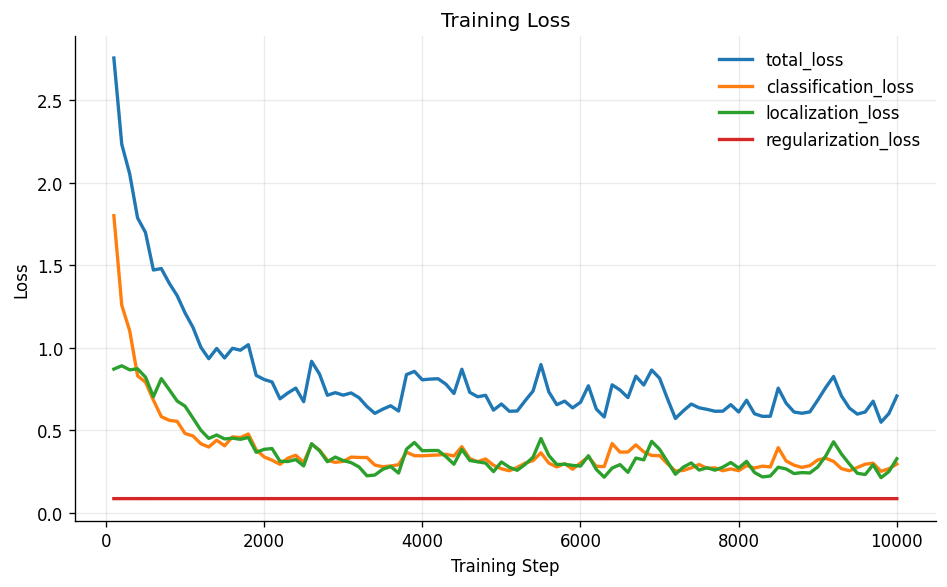

In [10]:
plot_loss_curves(
    train_df,
    smoothing=0.6,
    save_path="training_loss_curves.pdf",
)

(<Figure size 960x480 with 1 Axes>,
 <AxesSubplot: title={'center': 'Learning Rate Schedule'}, xlabel='Training Step', ylabel='Learning Rate'>)

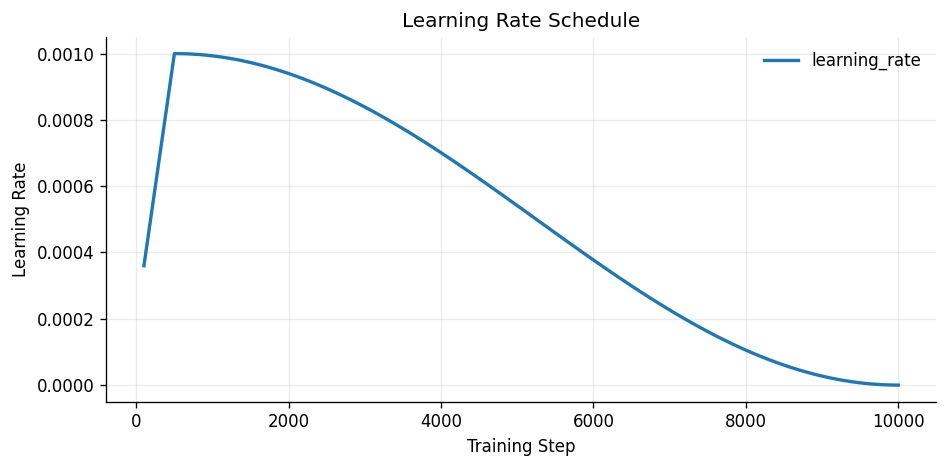

In [11]:
plot_learning_rate(
    train_df,
    save_path="learning_rate_schedule.pdf",
)

(<Figure size 960x480 with 1 Axes>,
 <AxesSubplot: title={'center': 'Training Throughput'}, xlabel='Training Step', ylabel='Steps / Second'>)

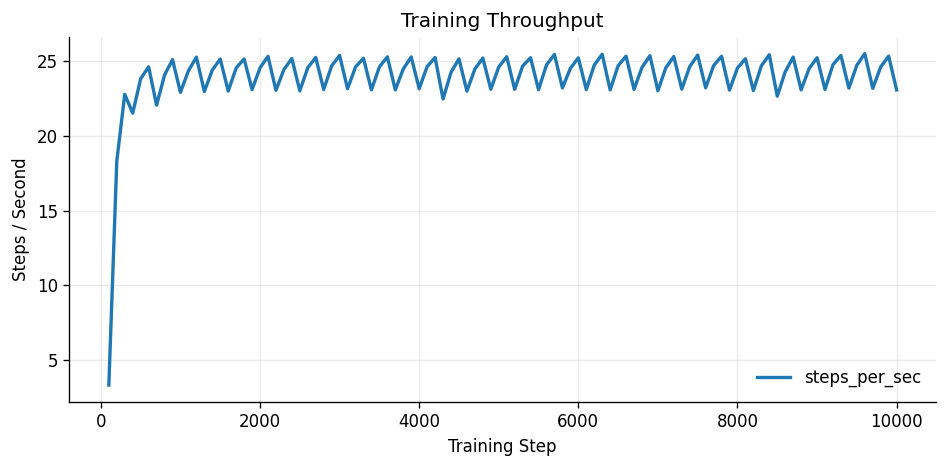

In [12]:
plot_steps_per_second(
    train_df,
    smoothing=0.5,
    save_path="training_throughput.pdf",
)

The generated figures are also exported as PDF files:

- `training_loss_curves.pdf`
- `learning_rate_schedule.pdf`
- `training_throughput.pdf`

These vector graphics are suitable for direct inclusion
in scientific publications and LaTeX-based theses.

In [13]:
# from agri_vision_edge.tfod import launch_eval

# launch_eval(
#     pipeline_config_path=PIPELINE_CONFIG,
#     checkpoint_dir="/kaggle/working/training",
#     model_dir="/kaggle/working/eval_output",
# )


## Validation and Checkpoint Selection

Instead of evaluating only the final checkpoint,
we evaluate all saved checkpoints throughout training.

This enables:

- training progression analysis
- mAP evolution tracking
- best checkpoint selection
- overfitting detection

In [14]:
from agri_vision_edge.evaluation import evaluate_checkpoints


metrics_df = evaluate_checkpoints(
    pipeline_config_path=PIPELINE_CONFIG,
    checkpoint_dir="/kaggle/working/training",
    output_dir="/kaggle/working/eval_checkpoints",
)

metrics_df

Evaluating checkpoint 1
<frozen importlib._bootstrap>:241: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
/opt/conda/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
W0510 11:43:37.169571 137810236475200 model_lib_v2.py:1089] Forced number of epochs for all eval validations to be 1.
I0510 11:43:37.169787 137810236475200 config_util.py:552] Maybe overwriting sample_1_of_n_eval_examples: None
I0510 11:43:37.169856 137810236475200 conf

,DetectionBoxes_Precision/mAP,DetectionBoxes_Precision/mAP@.50IOU,DetectionBoxes_Precision/mAP@.75IOU,DetectionBoxes_Precision/mAP (small),DetectionBoxes_Precision/mAP (medium),DetectionBoxes_Precision/mAP (large),DetectionBoxes_Recall/AR@1,DetectionBoxes_Recall/AR@10,DetectionBoxes_Recall/AR@100,DetectionBoxes_Recall/AR@100 (small),DetectionBoxes_Recall/AR@100 (medium),DetectionBoxes_Recall/AR@100 (large),Loss/localization_loss,Loss/classification_loss,Loss/regularization_loss,Loss/total_loss,checkpoint,step
0,0.000551,0.001641,0.000038,0.000000,0.000844,0.001389,0.001366,0.006657,0.013790,0.000000,0.020484,0.114669,2.119881,3.393410,0.085176,5.598467,/kaggle/working/training/ckpt-1,1
1,0.023651,0.073261,0.009264,0.001714,0.057985,0.106164,0.013436,0.055003,0.097299,0.017884,0.151749,0.294628,1.209339,0.631760,0.085201,1.926299,/kaggle/working/training/ckpt-2,2
2,0.045762,0.132277,0.021013,0.006265,0.135279,0.203193,0.020998,0.094983,0.141902,0.038285,0.297363,0.312810,0.872654,0.440868,0.085223,1.398745,/kaggle/working/training/ckpt-3,3
3,0.109340,0.247213,0.081380,0.026376,0.241630,0.242904,0.037482,0.166399,0.203456,0.085418,0.436294,0.453306,0.665844,0.384284,0.085236,1.135364,/kaggle/working/training/ckpt-4,4
4,0.144324,0.322448,0.116437,0.044041,0.292439,0.267330,0.045988,0.213114,0.254089,0.141261,0.469637,0.488430,0.547517,0.351884,0.085245,0.984647,/kaggle/working/training/ckpt-5,5
5,0.148926,0.337507,0.117050,0.047339,0.333261,0.292042,0.046041,0.227500,0.270492,0.155389,0.505445,0.523347,0.507317,0.322567,0.085250,0.915134,/kaggle/working/training/ckpt-6,6
6,0.165494,0.362600,0.137737,0.053484,0.342535,0.305051,0.049726,0.236121,0.276406,0.163045,0.500808,0.512810,0.476088,0.333235,0.085248,0.894571,/kaggle/working/training/ckpt-7,7
7,0.152656,0.348199,0.124338,0.049659,0.366494,0.305448,0.046556,0.238230,0.282552,0.168921,0.510368,0.561157,0.460659,0.298132,0.085246,0.844037,/kaggle/working/training/ckpt-8,8
8,0.174716,0.380248,0.149152,0.060082,0.382908,0.346241,0.049685,0.240779,0.280026,0.163665,0.525965,0.505992,0.457654,0.323596,0.085241,0.866491,/kaggle/working/training/ckpt-9,9
9,0.172818,0.367202,0.151658,0.064022,0.403173,0.359138,0.049976,0.248951,0.287098,0.166270,0.549845,0.516322,0.448707,0.293684,0.085238,0.827630,/kaggle/working/training/ckpt-10,10


## Validation Metrics

We evaluate all saved checkpoints using standard
COCO-style object detection metrics.

This enables analysis of:

- convergence behavior
- validation performance evolution
- checkpoint selection
- potential overfitting

In [15]:
metrics_df.columns

Index(['DetectionBoxes_Precision/mAP', 'DetectionBoxes_Precision/mAP@.50IOU',
       'DetectionBoxes_Precision/mAP@.75IOU',
       'DetectionBoxes_Precision/mAP (small)',
       'DetectionBoxes_Precision/mAP (medium)',
       'DetectionBoxes_Precision/mAP (large)', 'DetectionBoxes_Recall/AR@1',
       'DetectionBoxes_Recall/AR@10', 'DetectionBoxes_Recall/AR@100',
       'DetectionBoxes_Recall/AR@100 (small)',
       'DetectionBoxes_Recall/AR@100 (medium)',
       'DetectionBoxes_Recall/AR@100 (large)', 'Loss/localization_loss',
       'Loss/classification_loss', 'Loss/regularization_loss',
       'Loss/total_loss', 'checkpoint', 'step'],
      dtype='object')

In [16]:
metrics_df[
    [
        "step",
        "DetectionBoxes_Precision/mAP",
        "DetectionBoxes_Precision/mAP@.50IOU",
        "DetectionBoxes_Precision/mAP@.75IOU",
        "DetectionBoxes_Recall/AR@100",
    ]
]

,step,DetectionBoxes_Precision/mAP,DetectionBoxes_Precision/mAP@.50IOU,DetectionBoxes_Precision/mAP@.75IOU,DetectionBoxes_Recall/AR@100
0,1,0.000551,0.001641,0.000038,0.013790
1,2,0.023651,0.073261,0.009264,0.097299
2,3,0.045762,0.132277,0.021013,0.141902
3,4,0.109340,0.247213,0.081380,0.203456
4,5,0.144324,0.322448,0.116437,0.254089
5,6,0.148926,0.337507,0.117050,0.270492
6,7,0.165494,0.362600,0.137737,0.276406
7,8,0.152656,0.348199,0.124338,0.282552
8,9,0.174716,0.380248,0.149152,0.280026
9,10,0.172818,0.367202,0.151658,0.287098


In [17]:
metrics_df

,DetectionBoxes_Precision/mAP,DetectionBoxes_Precision/mAP@.50IOU,DetectionBoxes_Precision/mAP@.75IOU,DetectionBoxes_Precision/mAP (small),DetectionBoxes_Precision/mAP (medium),DetectionBoxes_Precision/mAP (large),DetectionBoxes_Recall/AR@1,DetectionBoxes_Recall/AR@10,DetectionBoxes_Recall/AR@100,DetectionBoxes_Recall/AR@100 (small),DetectionBoxes_Recall/AR@100 (medium),DetectionBoxes_Recall/AR@100 (large),Loss/localization_loss,Loss/classification_loss,Loss/regularization_loss,Loss/total_loss,checkpoint,step
0,0.000551,0.001641,0.000038,0.000000,0.000844,0.001389,0.001366,0.006657,0.013790,0.000000,0.020484,0.114669,2.119881,3.393410,0.085176,5.598467,/kaggle/working/training/ckpt-1,1
1,0.023651,0.073261,0.009264,0.001714,0.057985,0.106164,0.013436,0.055003,0.097299,0.017884,0.151749,0.294628,1.209339,0.631760,0.085201,1.926299,/kaggle/working/training/ckpt-2,2
2,0.045762,0.132277,0.021013,0.006265,0.135279,0.203193,0.020998,0.094983,0.141902,0.038285,0.297363,0.312810,0.872654,0.440868,0.085223,1.398745,/kaggle/working/training/ckpt-3,3
3,0.109340,0.247213,0.081380,0.026376,0.241630,0.242904,0.037482,0.166399,0.203456,0.085418,0.436294,0.453306,0.665844,0.384284,0.085236,1.135364,/kaggle/working/training/ckpt-4,4
4,0.144324,0.322448,0.116437,0.044041,0.292439,0.267330,0.045988,0.213114,0.254089,0.141261,0.469637,0.488430,0.547517,0.351884,0.085245,0.984647,/kaggle/working/training/ckpt-5,5
5,0.148926,0.337507,0.117050,0.047339,0.333261,0.292042,0.046041,0.227500,0.270492,0.155389,0.505445,0.523347,0.507317,0.322567,0.085250,0.915134,/kaggle/working/training/ckpt-6,6
6,0.165494,0.362600,0.137737,0.053484,0.342535,0.305051,0.049726,0.236121,0.276406,0.163045,0.500808,0.512810,0.476088,0.333235,0.085248,0.894571,/kaggle/working/training/ckpt-7,7
7,0.152656,0.348199,0.124338,0.049659,0.366494,0.305448,0.046556,0.238230,0.282552,0.168921,0.510368,0.561157,0.460659,0.298132,0.085246,0.844037,/kaggle/working/training/ckpt-8,8
8,0.174716,0.380248,0.149152,0.060082,0.382908,0.346241,0.049685,0.240779,0.280026,0.163665,0.525965,0.505992,0.457654,0.323596,0.085241,0.866491,/kaggle/working/training/ckpt-9,9
9,0.172818,0.367202,0.151658,0.064022,0.403173,0.359138,0.049976,0.248951,0.287098,0.166270,0.549845,0.516322,0.448707,0.293684,0.085238,0.827630,/kaggle/working/training/ckpt-10,10


(<Figure size 1200x1200 with 3 Axes>,
 array([<AxesSubplot: title={'center': 'Validation Precision'}, ylabel='mAP'>,
        <AxesSubplot: title={'center': 'Validation Recall'}, ylabel='Average Recall'>,
        <AxesSubplot: title={'center': 'Validation Loss'}, xlabel='Checkpoint Step', ylabel='Loss'>],
       dtype=object))

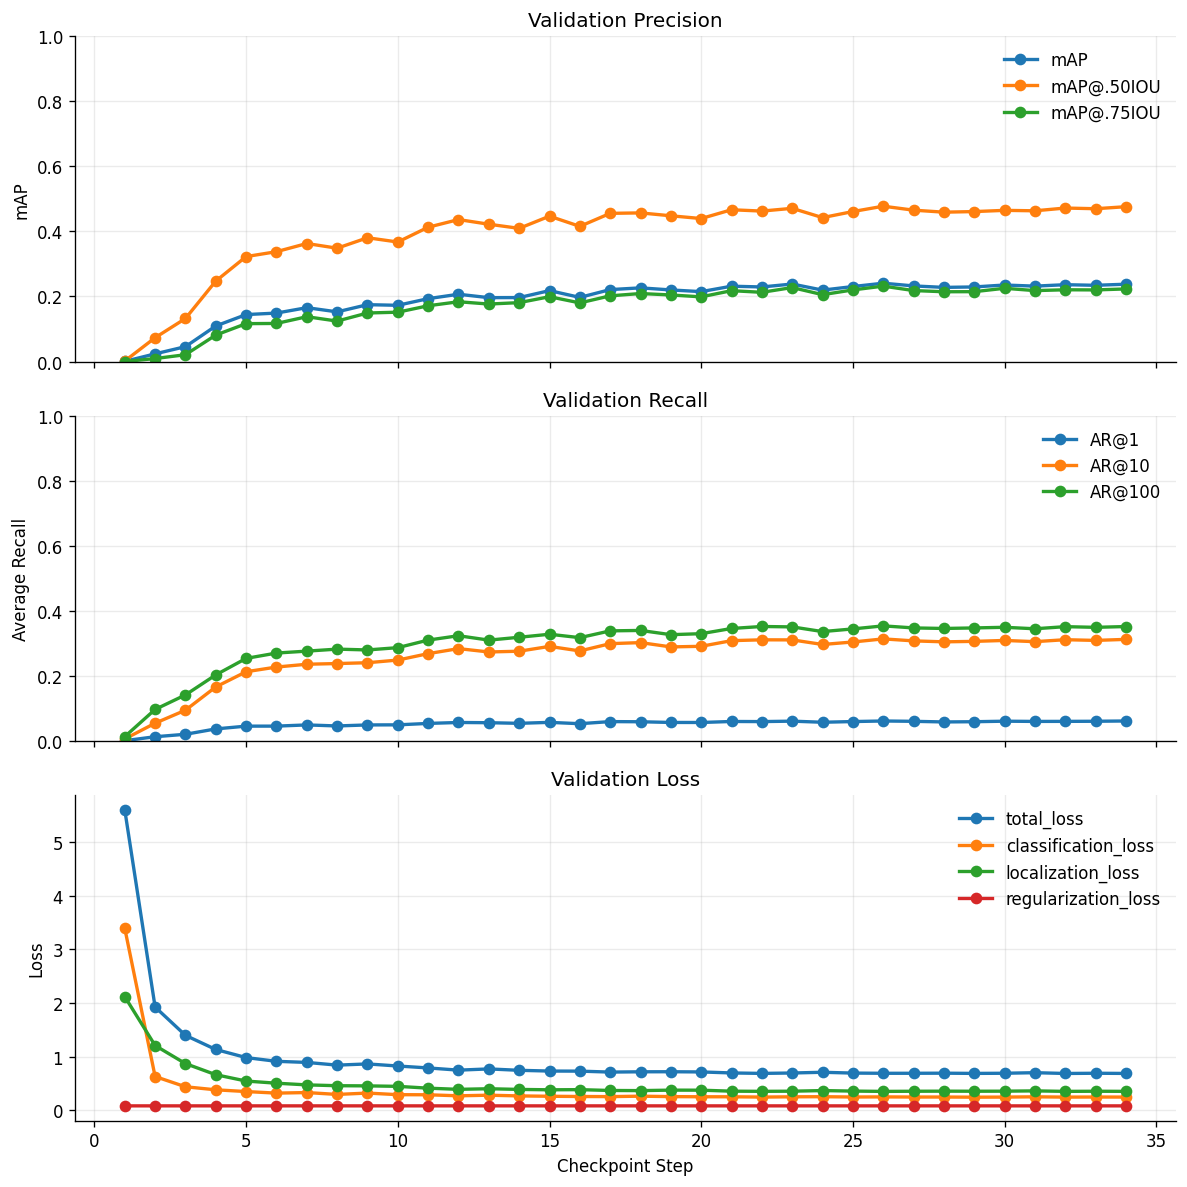

In [18]:
from agri_vision_edge.evaluation import plot_checkpoint_metrics

plot_checkpoint_metrics(
    metrics_df,
)

In [19]:
from agri_vision_edge.evaluation import find_best_checkpoint

best_checkpoint = find_best_checkpoint(
    metrics_df,
    metric="DetectionBoxes_Precision/mAP",
)

best_checkpoint

DetectionBoxes_Precision/mAP                                      0.24068
DetectionBoxes_Precision/mAP@.50IOU                              0.477187
DetectionBoxes_Precision/mAP@.75IOU                              0.231681
DetectionBoxes_Precision/mAP (small)                             0.115249
DetectionBoxes_Precision/mAP (medium)                             0.46398
DetectionBoxes_Precision/mAP (large)                             0.499347
DetectionBoxes_Recall/AR@1                                       0.061814
DetectionBoxes_Recall/AR@10                                      0.314003
DetectionBoxes_Recall/AR@100                                     0.353988
DetectionBoxes_Recall/AR@100 (small)                             0.243559
DetectionBoxes_Recall/AR@100 (medium)                            0.606274
DetectionBoxes_Recall/AR@100 (large)                             0.661157
Loss/localization_loss                                           0.354696
Loss/classification_loss              

## Model Export

We export the trained model in two formats:

- a standard TensorFlow SavedModel for generic TensorFlow
  inference workflows
- a TensorFlow Lite–compatible export graph for quantization
  and embedded deployment

The TensorFlow Lite export path uses TensorFlow Object
Detection's dedicated TFLite exporter, which rewrites the
graph for improved compatibility with:

- TensorFlow Lite conversion
- post-training quantization
- embedded accelerators
- NPU delegates such as TIM-VX / Teflon

This export path typically reduces dynamic TensorFlow ops
and improves deployment compatibility on edge devices.

In [20]:
from agri_vision_edge.tfod import export_saved_model

export_saved_model(
    pipeline_config_path=PIPELINE_CONFIG,
    trained_checkpoint_dir="/kaggle/working/training",
    checkpoint_path=best_checkpoint["checkpoint"],
    output_directory="/kaggle/working/exported_model",
)

<frozen importlib._bootstrap>:241: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
/opt/conda/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
W0510 12:13:58.652945 140261376153408 deprecation.py:350] From /opt/conda/lib/python3.10/site-packages/tensorflow/python/autograph/pyct/static_analysis/liveness.py:83: Analyzer.lamba_check (from tensorflow.python.autograph.pyct.static_analysis.liveness) is deprecated and will be removed after 

<Popen: returncode: 0 args: ['python', '/opt/conda/lib/python3.10/site-packa...>

In [21]:
from agri_vision_edge.tfod import export_tflite_graph

export_tflite_graph(
    pipeline_config_path=PIPELINE_CONFIG,
    trained_checkpoint_dir="/kaggle/working/training",
    checkpoint_path=best_checkpoint["checkpoint"],
    output_directory="/kaggle/working/tflite_export",
)

<frozen importlib._bootstrap>:241: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
/opt/conda/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
I0510 12:14:46.557100 133466220558144 api.py:459] feature_map_spatial_dims: [(19, 19), (10, 10), (5, 5), (3, 3), (2, 2), (1, 1)]
I0510 12:14:48.127664 133466220558144 convolutional_keras_box_predictor.py:152] depth of additional conv before box predictor: 0
I0510 12:14:48.127986 13346622055814

<Popen: returncode: 0 args: ['python', '/opt/conda/lib/python3.10/site-packa...>

## Remove Checkpoints to prevent storage bloat.

In [22]:
!rm -rf {training,eval_checkpoints}

## Qualitative Evaluation

We visualize predictions on unseen test images.

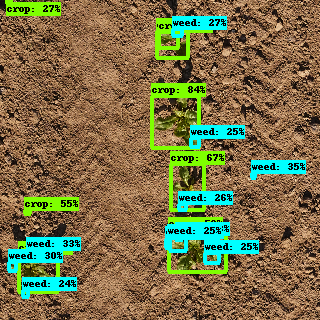

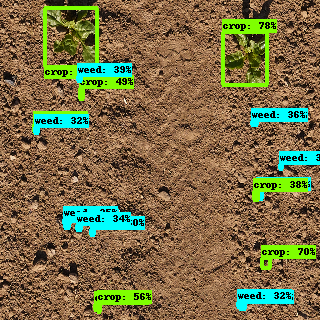

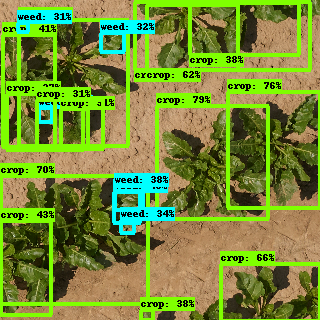

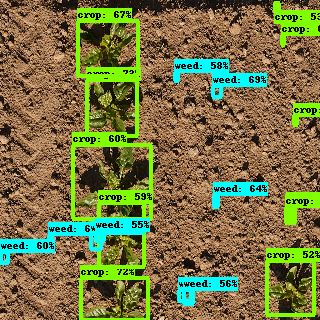

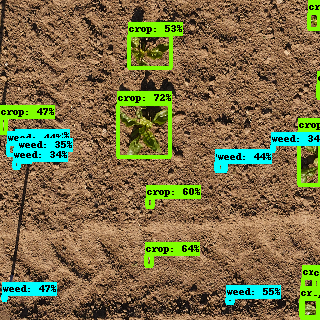

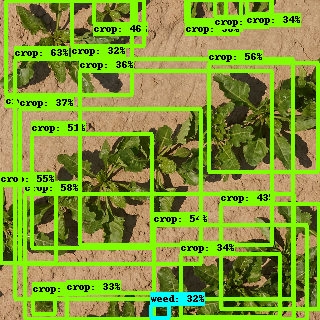

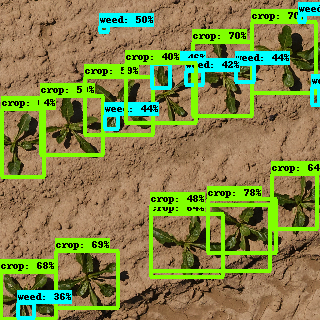

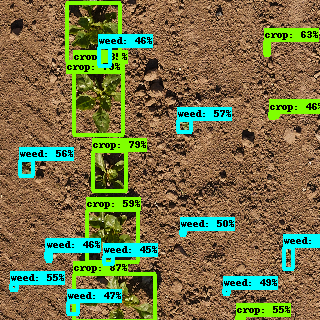

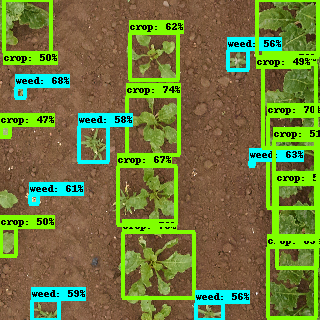

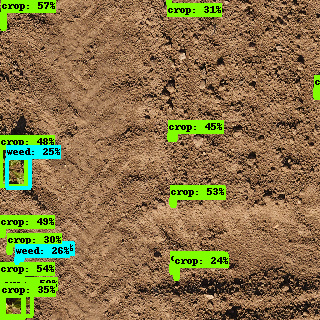

In [23]:
from IPython.display import display
from agri_vision_edge.tfod.inference import (
    load_saved_model,
    load_label_map,
    detect_image,
)

detect_fn = load_saved_model(
    "/kaggle/working/exported_model/saved_model"
)

category_index = load_label_map(label_map_path)

for image_path in test_imgs[:10]:
    vis, _ = detect_image(
        detect_fn=detect_fn,
        image_path=image_path,
        category_index=category_index,
        image_size=320,
        score_threshold=0.2,
        max_boxes=20,
    )
    display(vis)

## Discussion

The model demonstrates:

- Successful localization of plant instances
- Overlapping detections reduced via NMS
- Sensitivity to small objects (PhenoBench-specific challenge)

Limitations:
- Performance depends strongly on resolution (320×320)
- Dense scenes produce multiple candidate detections
- Further improvements possible via:
  - anchor tuning
  - longer training
  - quantization-aware training (QAT)

Future work:
- INT8 deployment via TFLite
- Real-time inference optimization